# Example 06: Window comparison — parameter estimation accuracy

This notebook examines how window choice affects parameter estimation in two complementary scenarios.

**Scenario 1 — isolated peak:** A single sinusoid in Gaussian noise. The Cramér–Rao bound (CRB) is set by the raw, unweighted data and is independent of the window. Any non-rectangular window discards information by downweighting samples near the record boundaries; the resulting variance inflation cannot be recovered by corrections.

**Scenario 2 — unmodeled interferer:** A second sinusoid nearby whose frequency falls outside the fit mask but whose sidelobes leak in. Here the sidelobe suppression of windowed estimators becomes an asset: the same information loss that hurts in scenario 1 now attenuates the interferer's leakage. The degradation is largest when the interferer sits between two bins (d = 0.5), where sidelobe levels at the target frequency are highest.

*Implementation: `SineFourier`, `WindowType` in [dft/config.py](../dftmodels/dft/config.py); `Sinusoid.crb` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

In [1]:
# Imports and constants
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
plt.style.use("dftmodels.mplstyle")

from dftmodels import (
    SignalSeries, NormType, WindowType, DFTRange,
    DFTCorrection, DFTCorrectionMode, SineFourier, Sinusoid,
)

SAMPLE_RATE    = 1000.0    # Hz
N_SAMPLES      = 1000      # → bin spacing Δf = 1 Hz, duration = 1 s
TRUE_FREQUENCY = 100.0     # Hz  (exact bin centre)
TRUE_AMPLITUDE = 1.0       # V
NOISE_RMS      = 0.05      # V   → SNR ≈ 26 dB
BIN_SPACING    = SAMPLE_RATE / N_SAMPLES
DFT_RANGE      = DFTRange.SINGLE_SIDED
MASK_WIDTH     = 2.0       # Hz — fit window half-width

t  = np.arange(N_SAMPLES) / SAMPLE_RATE
ai = TRUE_AMPLITUDE   # amplitude_q = 0  →  pure cosine

# Scenario 1
N_REALIZATIONS = 300
DELTA_VALUES   = np.array([0.0, 0.5])   # fractional bin offset of target

# Scenario 2
N_REALIZATIONS_2   = 100
INTERFERER_BINS    = 5                              # integer bin separation from target
INTERFERER_OFFSETS = np.linspace(0, 1, 32, endpoint=True)  # fractional offset of interferer

WINDOWS_1 = [
    ("Rectangular", WindowType.RECTANGULAR),
    ("Hann"       , WindowType.HANN       ),
    ("Hamming"    , WindowType.HAMMING    ),
    ("Blackman"   , WindowType.BLACKMAN   ),
    ("Nuttall"    , WindowType.NUTTAL     ),
    ("Flat-Top"   , WindowType.FLAT_TOP   ),
]

WINDOWS_2 =[
    ("Rectangular", WindowType.RECTANGULAR),
    ("Hamming"    , WindowType.HAMMING    ),
]


## Scenario 1: Isolated peak

The Cramér–Rao bound (CRB) is computed from the time-domain Fisher information matrix and is independent of the window. It is the minimum variance any unbiased estimator can achieve given the raw data — not the windowed spectrum. A windowed estimator can only match it in the limit of a rectangular window.

*Implementation: `Sinusoid.crb` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

In [2]:
# Cramér–Rao bounds — window-independent reference set by the raw data
_crb_params = SineFourier.make_params(amplitude_i=ai, amplitude_q=0.0, frequency=TRUE_FREQUENCY)
_crb        = Sinusoid.crb(_crb_params, t, NOISE_RMS)

CRB_FREQ = _crb["frequency"]   # σ in Hz
CRB_AMP  = _crb["amplitude"]   # σ in V

print(f"CRB  frequency : σ_f = {CRB_FREQ * 1e3:.4f} mHz")
print(f"CRB  amplitude : σ_A = {CRB_AMP  * 1e3:.4f} mV")

CRB  frequency : σ_f = 1.2328 mHz
CRB  amplitude : σ_A = 2.2361 mV


### Monte Carlo

300 noise realizations per (window, δ) pair. Two fractional bin offsets: δ = 0 (on-bin) and δ = 0.5 (worst-case). `DFTCorrectionMode.ALL` throughout — the comparison isolates window choice from correction level.

In [3]:
# Monte Carlo: RMSE for each window at δ = 0 and δ = 0.5
rng = np.random.default_rng(seed=42)

rmse_freq = np.zeros((len(WINDOWS_1), len(DELTA_VALUES)))
rmse_amp  = np.zeros((len(WINDOWS_1), len(DELTA_VALUES)))

for w_idx, (win_label, win_type) in enumerate(WINDOWS_1):
    _ref  = SignalSeries(x=t, y=Sinusoid.eval(t, ai, 0.0, TRUE_FREQUENCY)).calculate_dft(
        norm=NormType.ASD, window=win_type, dft_range=DFT_RANGE, pad=1.0,
    )
    model = SineFourier(_ref.dft_config, DFTCorrection(DFTCorrectionMode.ALL))

    for d_idx, delta in enumerate(DELTA_VALUES):
        true_freq = TRUE_FREQUENCY + delta * BIN_SPACING
        f_lo      = true_freq - MASK_WIDTH
        f_hi      = true_freq + MASK_WIDTH
        y_clean   = Sinusoid.eval(t, ai, 0.0, true_freq)

        freq_errors, amp_errors = [], []
        for _ in range(N_REALIZATIONS):
            y       = y_clean.copy()
            y      += rng.normal(scale=NOISE_RMS, size=N_SAMPLES)
            fourier = SignalSeries(x=t, y=y).calculate_dft(
                norm=NormType.ASD, window=win_type, dft_range=DFT_RANGE, pad=1.0,
            )
            mask   = (fourier.x >= f_lo) & (fourier.x <= f_hi)
            params = model.make_params(
                amplitude_i=ai, amplitude_q=0.0,
                frequency=true_freq,
                frequency_min=f_lo, frequency_max=f_hi,
            )
            p = model.fit(fourier, params, mask=mask).params
            freq_errors.append(model.center(p)   - true_freq)
            amp_errors.append(model.amplitude(p) - TRUE_AMPLITUDE)

        rmse_freq[w_idx, d_idx] = np.sqrt(np.mean(np.array(freq_errors) ** 2))
        rmse_amp[w_idx, d_idx]  = np.sqrt(np.mean(np.array(amp_errors)  ** 2))
        
    print(f"  {win_label}")

print("done")

  Rectangular
  Hann
  Hamming
  Blackman
  Nuttall
  Flat-Top
done


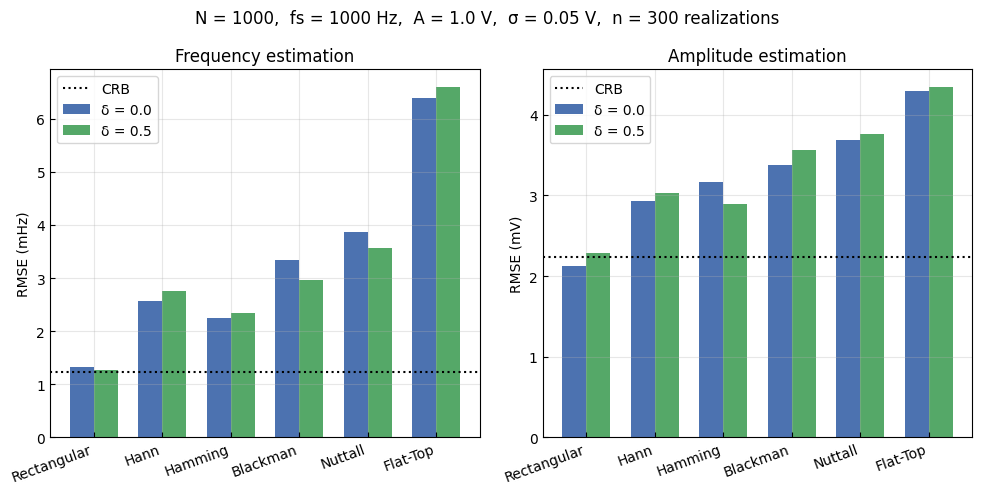

In [4]:
# Scenario 1: RMSE per window with CRB reference line
delta_labels = [f"δ = {d:.1f}" for d in DELTA_VALUES]
win_labels   = [w[0] for w in WINDOWS_1]
x            = np.arange(len(WINDOWS_1))
bar_w        = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for d_idx, dlabel in enumerate(delta_labels):
    offset = (d_idx - 0.5) * bar_w
    axes[0].bar(x + offset, rmse_freq[:, d_idx] * 1e3, bar_w, label=dlabel, color=f"C{d_idx}")
    axes[1].bar(x + offset, rmse_amp[:, d_idx]  * 1e3, bar_w, label=dlabel, color=f"C{d_idx}")

axes[0].axhline(CRB_FREQ * 1e3, color="black", ls=":", lw=1.5, label="CRB")
axes[1].axhline(CRB_AMP  * 1e3, color="black", ls=":", lw=1.5, label="CRB")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(win_labels, rotation=20, ha="right")
    ax.legend()

axes[0].set_ylabel("RMSE (mHz)")
axes[0].set_title("Frequency estimation")
axes[1].set_ylabel("RMSE (mV)")
axes[1].set_title("Amplitude estimation")

plt.suptitle(
    f"N = {N_SAMPLES},  fs = {SAMPLE_RATE:.0f} Hz,  A = {TRUE_AMPLITUDE} V,  "
    f"σ = {NOISE_RMS} V,  n = {N_REALIZATIONS} realizations"
)
plt.tight_layout()
plt.savefig(f"figures/06_window_comparison_fig00.svg", bbox_inches="tight")
plt.show()

In [5]:
# Scenario 1: RMSE and CRB tabular summary
print(f"{'Window':<14}  {'freq δ=0':>10}  {'freq δ=0.5':>11}  {'amp δ=0':>9}  {'amp δ=0.5':>10}")
print(f"{'':<14}  {'mHz':>10}  {'mHz':>11}  {'mV':>9}  {'mV':>10}")
print("-" * 62)
print(
    f"{'CRB':<14}  "
    f"{CRB_FREQ*1e3:>10.3f}  {'':11}  "
    f"{CRB_AMP*1e3:>9.3f}  {'':10}"
)
print("-" * 62)
for w_idx, (win_label, _) in enumerate(WINDOWS_1):
    print(
        f"{win_label:<14}  "
        f"{rmse_freq[w_idx, 0]*1e3:>10.3f}  {rmse_freq[w_idx, 1]*1e3:>11.3f}  "
        f"{rmse_amp[w_idx,  0]*1e3:>9.3f}  {rmse_amp[w_idx,  1]*1e3:>10.3f}"
    )

Window            freq δ=0   freq δ=0.5    amp δ=0   amp δ=0.5
                       mHz          mHz         mV          mV
--------------------------------------------------------------
CRB                  1.233                   2.236            
--------------------------------------------------------------
Rectangular          1.327        1.277      2.121       2.286
Hann                 2.563        2.749      2.937       3.034
Hamming              2.238        2.343      3.170       2.894
Blackman             3.337        2.969      3.372       3.569
Nuttall              3.869        3.569      3.690       3.765
Flat-Top             6.395        6.603      4.296       4.348


## Scenario 2: Unmodeled interferer

A second sinusoid at the same amplitude as the target is placed `INTERFERER_BINS` bins away. Its frequency falls outside the fit mask, so it is not included in the model. Its spectral sidelobes leak into the fit region and bias the parameter estimates. The interferer's fractional bin offset δ is swept from 0 to 1; at δ = 0.5 the interferer sits between two bins, which is where sidelobe leakage at the target frequency is highest.

For the rectangular window the sidelobes decay as 1/(πk) (sinc), so leakage from a nearby interferer is substantial. Windowed estimators suppress sidelobes at the cost of the Fisher information loss quantified in scenario 1.

No CRB is shown: the effective noise is no longer Gaussian (a coherent leakage component is superimposed), so the time-domain CRB does not apply.

In [6]:
# Scenario 2: RMSE vs interferer fractional offset, random interferer phase each realization
rng2 = np.random.default_rng(seed=43)

y_target = Sinusoid.eval(t, ai, 0.0, TRUE_FREQUENCY)
f_lo     = TRUE_FREQUENCY - MASK_WIDTH
f_hi     = TRUE_FREQUENCY + MASK_WIDTH

rmse_freq2 = np.zeros((len(WINDOWS_2), len(INTERFERER_OFFSETS)))
rmse_amp2  = np.zeros((len(WINDOWS_2), len(INTERFERER_OFFSETS)))

for w_idx, (win_label, win_type) in enumerate(WINDOWS_2):
    _ref  = SignalSeries(x=t, y=y_target).calculate_dft(
        norm=NormType.ASD, window=win_type, dft_range=DFT_RANGE, pad=1.0,
    )
    model = SineFourier(_ref.dft_config, DFTCorrection(DFTCorrectionMode.ALL))

    for o_idx, d in enumerate(INTERFERER_OFFSETS):
        f_int = TRUE_FREQUENCY + INTERFERER_BINS * BIN_SPACING + d * BIN_SPACING

        freq_errors, amp_errors = [], []
        for _ in range(N_REALIZATIONS_2):
            phase = rng2.uniform(0.0, 2 * np.pi)
            y     = y_target.copy()
            y    += rng2.normal(scale=NOISE_RMS, size=N_SAMPLES)
            y    += Sinusoid.eval(t, ai * np.cos(phase), ai * np.sin(phase), f_int)
            fourier = SignalSeries(x=t, y=y).calculate_dft(
                norm=NormType.ASD, window=win_type, dft_range=DFT_RANGE, pad=1.0,
            )
            mask   = (fourier.x >= f_lo) & (fourier.x <= f_hi)
            params = model.make_params(
                amplitude_i=ai, amplitude_q=0.0,
                frequency=TRUE_FREQUENCY,
                frequency_min=f_lo, frequency_max=f_hi,
            )
            p = model.fit(fourier, params, mask=mask).params
            freq_errors.append(model.center(p)   - TRUE_FREQUENCY)
            amp_errors.append(model.amplitude(p) - TRUE_AMPLITUDE)

        rmse_freq2[w_idx, o_idx] = np.sqrt(np.mean(np.array(freq_errors) ** 2))
        rmse_amp2[w_idx, o_idx]  = np.sqrt(np.mean(np.array(amp_errors)  ** 2))

    print(f"  {win_label}")

print("done")

  Rectangular
  Hamming
done


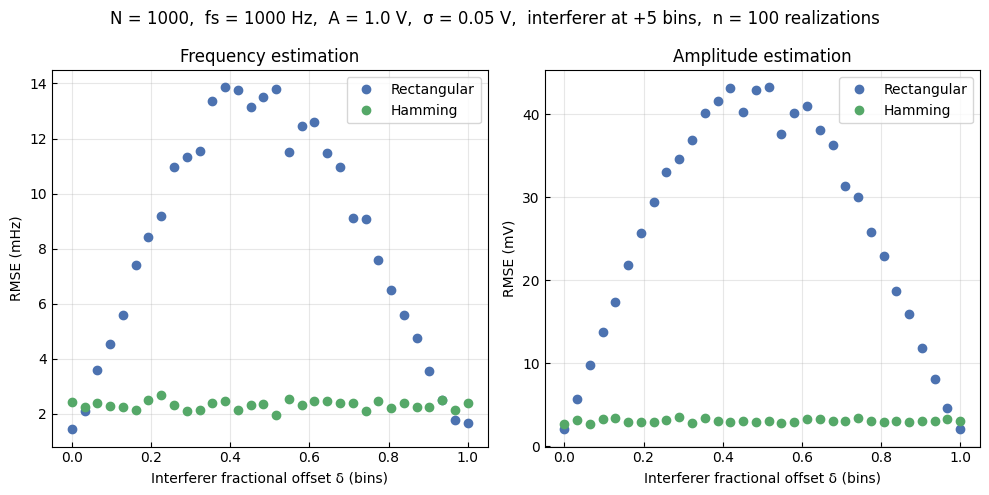

In [7]:
# Scenario 2: RMSE vs interferer fractional offset, one line per window
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for w_idx, (win_label, _) in enumerate(WINDOWS_2):
    axes[0].plot(INTERFERER_OFFSETS, rmse_freq2[w_idx] * 1e3,
                 label=win_label, color=f"C{w_idx}", marker="o", ls="None")
    axes[1].plot(INTERFERER_OFFSETS, rmse_amp2[w_idx]  * 1e3,
                 label=win_label, color=f"C{w_idx}", marker="o", ls="None")

for ax in axes:
    ax.set_xlabel("Interferer fractional offset δ (bins)")
    ax.legend()

axes[0].set_ylabel("RMSE (mHz)")
axes[0].set_title("Frequency estimation")
axes[1].set_ylabel("RMSE (mV)")
axes[1].set_title("Amplitude estimation")

plt.suptitle(
    f"N = {N_SAMPLES},  fs = {SAMPLE_RATE:.0f} Hz,  A = {TRUE_AMPLITUDE} V,  "
    f"σ = {NOISE_RMS} V,  interferer at +{INTERFERER_BINS} bins,  n = {N_REALIZATIONS_2} realizations"
)
plt.tight_layout()
plt.savefig(f"figures/06_window_comparison_fig01.svg", bbox_inches="tight")
plt.show()

In [8]:
# Scenario 2: RMSE at worst-case interferer offset (d ≈ 0.5)
worst_idx = np.argmin(np.abs(INTERFERER_OFFSETS - 0.5))
d_worst   = INTERFERER_OFFSETS[worst_idx]

print(f"Interferer at +{INTERFERER_BINS} bins,  fractional offset δ = {d_worst:.3f}\n")
hdr = f"{'Window':<14}  {'freq RMSE (mHz)':>16}  {'amp RMSE (mV)':>14}"
print(hdr)
print("-" * len(hdr))
for w_idx, (win_label, _) in enumerate(WINDOWS_2):
    print(
        f"{win_label:<14}  "
        f"{rmse_freq2[w_idx, worst_idx]*1e3:>16.3f}  "
        f"{rmse_amp2[w_idx,  worst_idx]*1e3:>14.3f}"
    )

Interferer at +5 bins,  fractional offset δ = 0.484

Window           freq RMSE (mHz)   amp RMSE (mV)
------------------------------------------------
Rectangular               13.498          42.944
Hamming                    2.335           2.906


## Summary

**Scenario 1 — isolated peak:** The CRB is set by the raw data and is independent of the window. Any non-rectangular window discards information by downweighting samples near the record boundaries; the resulting variance inflation cannot be undone by corrections. The rectangular window is the only window whose RMSE approaches the CRB.

**Scenario 2 — unmodeled interferer:** When a nearby peak is absent from the model, its sidelobes contaminate the fit. Rectangular windows have the broadest sidelobe structure (∝ sinc), so their estimators are most sensitive to this leakage. Windowed estimators suppress sidelobes at the cost of Fisher information. The degradation peaks at δ = 0.5, where the interferer sits between bins and its sidelobe level at the target is highest.